# Clean Electricity Low-Income Eligibility and NYC Outage Vulnerability

**Purpose:** Evaluate whether the current Clean Electricity low-income eligibility layer (2025 tract geography) aligns with NYC's historical outage burden from 2014-2023, and assess whether eligibility provides useful policy context alongside CVI, severe weather, and duration measures.

The eligibility file is a 2025 tract-level cross-sectional layer. It is not a time-varying 2014-2023 exposure, so this notebook treats it as a current policy benchmark rather than as an annual causal covariate.


## Executive Summary

- **Direct tract match is high:** the Clean Electricity workbook matches 2,033 of 2,168 NYC outage/CVI tracts, or **93.8%**. The remaining gap is consistent with tract geography changes and would require a Census tract crosswalk for exact recovery.
- **The new layer is policy-relevant but not independent of CVI:** Category 1 eligibility is strongly correlated with social-economic CVI, so it adds a clean-energy policy lens rather than replacing the vulnerability indicators already used in the outage analysis.
- **Policy alignment is real but imperfect:** tracts with 100% current Category 1 eligibility have higher average social-economic CVI than 0% Category 1 tracts, but their 2014-2023 outage event counts are similar rather than clearly higher. This suggests the eligibility layer identifies social vulnerability better than it isolates the highest historical outage-count burden.
- **Tract-year models are diagnostic only:** because the underlying outage structure is largely county-year based, tract-level regressions should be used for screening and maps, not final inference.
- **Best use in the project:** frame this dataset as a **current policy benchmark** for comparing clean-energy eligibility with historical outage burden, while keeping the main outage inference grounded in severe weather, CVI, county-month frequency models, and event-level duration models.


## Analysis Questions

1. How much of the NYC outage/CVI tract universe matches the 2025 Clean Electricity low-income tract layer?
2. How do current Clean Electricity eligibility measures compare with CVI across NYC counties and tracts?
3. Are communities that are currently eligible under Clean Electricity low-income criteria also the communities that experienced higher outage burden during 2014-2023?
4. As a secondary sensitivity check, do eligibility measures add signal to compact county-year or event-duration models after accounting for severe weather and CVI?


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 220)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
OUT_DIR = PROJECT_DIR / "output" / "jupyter-notebook" / "clean_electricity_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

NYC_COUNTIES = {
    "36005": "Bronx",
    "36047": "Brooklyn",
    "36061": "Manhattan",
    "36081": "Queens",
    "36085": "Staten Island",
}

CVI_COLS = [
    "cvi_overall",
    "cvi_baseline_social_econ",
    "cvi_baseline_infra",
    "cvi_climate_extreme_events",
]

ELIGIBILITY_COLS = [
    "clean_category1_pct",
    "clean_asc_ppc_pct",
    "clean_asc_cejst_e_pct",
    "clean_any_eligible_pct",
]

RANDOM_STATE = 42  # for reproducibility

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR :", OUT_DIR)

DATA_DIR: /Users/simonwang/Desktop/CU/Energy Project
OUT_DIR : /Users/simonwang/Desktop/CU/Energy Project/output/jupyter-notebook/clean_electricity_outputs


In [2]:
def clean_fips(series: pd.Series, width: int) -> pd.Series:
    return (
        pd.to_numeric(series, errors="coerce")
        .astype("Int64")
        .astype(str)
        .str.zfill(width)
        .replace({"<NA>": np.nan})
    )


def zscore(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    # ddof=0 (population std) used intentionally for consistency across this notebook.
    out = frame.copy()
    for col in columns:
        std = out[col].std(ddof=0)
        out[f"z_{col}"] = (
            (out[col] - out[col].mean()) / std
            if pd.notna(std) and std > 0
            else np.nan
        )
    return out


def fit_ols(formula: str, data: pd.DataFrame, label: str) -> tuple[dict, pd.DataFrame]:
    fit = smf.ols(formula, data=data).fit(cov_type="HC3")
    conf = fit.conf_int()
    model_row = {
        "model": label,
        "formula": formula,
        "nobs": int(fit.nobs),
        "r2": fit.rsquared,
        "adj_r2": fit.rsquared_adj,
        "aic": fit.aic,
        "bic": fit.bic,
    }
    coef_rows = []
    for term in fit.params.index:
        coef_rows.append({
            "model": label,
            "term": term,
            "coef": fit.params[term],
            "std_error": fit.bse[term],
            "p_value": fit.pvalues[term],
            "ci_lower": conf.loc[term, 0],
            "ci_upper": conf.loc[term, 1],
        })
    return model_row, pd.DataFrame(coef_rows)

## Load and Clean Outage/CVI Data

This follows the previous notebook's geography and time window: NYC's five counties, 2014-2023. Severe weather is flagged the same way as before, using `outage_event_type` values that begin with `severe weather`.

In [3]:
outage = pd.read_csv(DATA_DIR / "Outage_CVI_Events.csv", low_memory=False)
outage["county_fips"] = clean_fips(outage["county_fips"], 5)
outage["tract_fips"] = clean_fips(outage["tract_fips"], 11)
outage = outage[outage["county_fips"].isin(NYC_COUNTIES)].copy()

outage["event_dt"] = pd.to_datetime(outage["outage_start_time"], errors="coerce")
outage["year"] = outage["event_dt"].dt.year
outage["month"] = outage["event_dt"].dt.month
outage["duration_hours"] = pd.to_numeric(outage["outage_duration_hours"], errors="coerce")
for col in ["outage_mean_customers", "outage_max_customers"]:
    if col in outage.columns:
        outage[col] = pd.to_numeric(outage[col], errors="coerce")

event_text = outage["outage_event_type"].fillna("").astype(str).str.strip().str.lower()
outage["severe_weather_flag"] = event_text.str.startswith("severe weather").astype(int)
outage = outage[outage["year"].between(2014, 2023, inclusive="both")].copy()
outage["county_name"] = outage["county_fips"].map(NYC_COUNTIES)

summary = outage.groupby("county_name", as_index=False).agg(
    events=("outage_event_uid", "nunique"),
    rows=("outage_event_uid", "size"),
    tracts=("tract_fips", "nunique"),
    mean_duration_hours=("duration_hours", "mean"),
)
display(summary.round(2))
print("Study years:", int(outage["year"].min()), "-", int(outage["year"].max()))
print("NYC tracts in outage/CVI data:", outage["tract_fips"].nunique())

,county_name,events,rows,tracts,mean_duration_hours
0,Bronx,865,420699,339,3.53
1,Brooklyn,1040,1063117,761,4.76
2,Manhattan,262,98496,288,3.47
3,Queens,1786,1550742,669,2.96
4,Staten Island,565,67821,111,3.31


Study years: 2014 - 2023
NYC tracts in outage/CVI data: 2168


## Load Clean Electricity Low-Income Eligibility Layer

The workbook is national and tract-level. Here it is filtered to the same five NYC counties and renamed into analysis-friendly columns.

In [4]:
clean_raw = pd.read_excel(
    DATA_DIR / "CleanElectricityLowIncome_Excel_20260217.xlsx",
    sheet_name="2025 Tract percentages",
    dtype={"Census Tract GEOID 2025": str, "State FIPS": str, "County FIPS": str},
)

clean = clean_raw[
    (clean_raw["State Name"].eq("New York"))
    & clean_raw["County Name"].isin([
        "Bronx County", "Kings County", "New York County", "Queens County", "Richmond County"
    ])
].copy()
clean["tract_fips"] = clean["Census Tract GEOID 2025"].str.zfill(11)
clean["county_fips"] = "36" + clean["County FIPS"].astype(str).str.zfill(3)
clean = clean.rename(columns={
    "Percent in Category 1": "clean_category1_pct",
    "Percent in ASC PPC": "clean_asc_ppc_pct",
    "Percent in ASC CEJST-E": "clean_asc_cejst_e_pct",
})
clean["clean_any_eligible_pct"] = clean[
    ["clean_category1_pct", "clean_asc_ppc_pct", "clean_asc_cejst_e_pct"]
].max(axis=1)
clean = clean[[
    "tract_fips", "county_fips", "County Name",
    "clean_category1_pct", "clean_asc_ppc_pct", "clean_asc_cejst_e_pct", "clean_any_eligible_pct",
]].drop_duplicates("tract_fips")
clean["county_name"] = clean["county_fips"].map(NYC_COUNTIES)

display(clean.groupby("county_name")[ELIGIBILITY_COLS].agg(["count", "mean", "median", "max"]).round(2))
print("NYC tracts in Clean Electricity workbook:", clean["tract_fips"].nunique())

clean_category1_pct                      clean_asc_ppc_pct                      clean_asc_cejst_e_pct                     clean_any_eligible_pct                      
                            count   mean median    max             count   mean median    max                 count  mean median    max                  count    mean median    max
county_name                                                                                                                                                                         
Bronx                         361  78.12  100.0  100.0               361  100.0  100.0  100.0                   361  6.66    0.0  100.0                    361  100.00  100.0  100.0
Brooklyn                      804  57.84  100.0  100.0               804    0.0    0.0    0.0                   804  2.61    0.0  100.0                    804   57.84  100.0  100.0
Manhattan                     310  36.45    0.0  100.0               310    0.0    0.0    0.0                   310  0.00    0.0    0.0                    310   36.45    0.0  100.0
Queens                        724  42.40    0.0  100.0               724    0.0    0.0    0.0                   724  1.38    0.0  100.0                    724   42.53    0.0  100.0
Staten Island                 125  24.00    0.0  100.0               125    0.0    0.0    0.0                   125  5.59    0.0  100.0                    125   24.00    0.0  100.0

NYC tracts in Clean Electricity workbook: 2324


## Join Coverage

This uses direct GEOID matching. The direct match is high, but not perfect, because the workbook uses 2025 tract geography. Older tracts split into newer 2025 tract IDs will not match without a crosswalk.

In [5]:
tract_cvi = (
    outage[["tract_fips", "county_fips"] + CVI_COLS]
    .sort_values(["tract_fips", "county_fips"])
    .groupby(["tract_fips", "county_fips"], as_index=False)
    .first()
)
tract_features = tract_cvi.merge(clean.drop(columns="county_name"), on=["tract_fips", "county_fips"], how="left")
tract_features["clean_direct_match"] = tract_features["clean_category1_pct"].notna()
tract_features["county_name"] = tract_features["county_fips"].map(NYC_COUNTIES)

match_by_county = tract_features.groupby("county_name", as_index=False).agg(
    outage_tracts=("tract_fips", "nunique"),
    matched_tracts=("clean_direct_match", "sum"),
)
match_by_county["match_rate"] = match_by_county["matched_tracts"] / match_by_county["outage_tracts"]

display(match_by_county.round(3))
print("Overall direct match rate:", round(tract_features["clean_direct_match"].mean(), 3))
print("Directly matched tracts:", int(tract_features["clean_direct_match"].sum()), "of", tract_features["tract_fips"].nunique())

display(tract_features.loc[~tract_features["clean_direct_match"], ["tract_fips", "county_name"]].head(10))
tract_features.to_csv(OUT_DIR / "clean_electricity_tract_features.csv", index=False)

,county_name,outage_tracts,matched_tracts,match_rate
0,Bronx,339,323,0.953
1,Brooklyn,761,721,0.947
2,Manhattan,288,272,0.944
3,Queens,669,622,0.930
4,Staten Island,111,95,0.856


Overall direct match rate: 0.938
Directly matched tracts: 2033 of 2168


,tract_fips,county_name
4,36005001900,Bronx
5,36005002000,Bronx
36,36005006300,Bronx
60,36005009300,Bronx
65,36005011700,Bronx
115,36005018500,Bronx
219,36005030200,Bronx
237,36005033600,Bronx
239,36005033800,Bronx
274,36005038302,Bronx


## Descriptive Equity Comparison

This compares the new eligibility layer with CVI. In the direct-match tract set, Category 1 eligibility is strongly correlated with overall and social-economic CVI, so the new layer is policy-relevant but not independent of the existing vulnerability measures.

In [6]:
county_features = (
    tract_features.groupby("county_fips", as_index=False)
    .agg(
        matched_tracts=("clean_direct_match", "sum"),
        total_tracts=("tract_fips", "nunique"),
        cvi_overall_mean=("cvi_overall", "mean"),
        cvi_baseline_social_econ_mean=("cvi_baseline_social_econ", "mean"),
        cvi_baseline_infra_mean=("cvi_baseline_infra", "mean"),
        cvi_climate_extreme_events_mean=("cvi_climate_extreme_events", "mean"),
        clean_category1_mean=("clean_category1_pct", "mean"),
        clean_asc_ppc_mean=("clean_asc_ppc_pct", "mean"),
        clean_asc_cejst_e_mean=("clean_asc_cejst_e_pct", "mean"),
        clean_any_eligible_mean=("clean_any_eligible_pct", "mean"),
    )
)
county_features["match_rate"] = county_features["matched_tracts"] / county_features["total_tracts"]
county_features["county_name"] = county_features["county_fips"].map(NYC_COUNTIES)
display(county_features[[
    "county_name", "total_tracts", "matched_tracts", "match_rate",
    "clean_category1_mean", "clean_asc_ppc_mean", "clean_asc_cejst_e_mean", "clean_any_eligible_mean",
    "cvi_baseline_social_econ_mean",
]].round(3))

corr_rows = []
corr_vars = ELIGIBILITY_COLS + CVI_COLS
corr_base = tract_features.dropna(subset=["clean_category1_pct"])
for i, x in enumerate(corr_vars):
    for y in corr_vars[i + 1:]:
        valid = corr_base[[x, y]].dropna()
        rho, p_value = spearmanr(valid[x], valid[y])
        corr_rows.append({"x": x, "y": y, "spearman_rho": rho, "p_value": p_value, "n": len(valid)})
corr_df = pd.DataFrame(corr_rows).sort_values("spearman_rho", key=lambda s: s.abs(), ascending=False)
display(corr_df.head(12).round(4))
corr_df.to_csv(OUT_DIR / "clean_electricity_correlations.csv", index=False)

,county_name,total_tracts,matched_tracts,match_rate,clean_category1_mean,clean_asc_ppc_mean,clean_asc_cejst_e_mean,clean_any_eligible_mean,cvi_baseline_social_econ_mean
0,Bronx,339,323,0.953,79.568,99.997,7.439,100.000,0.761
1,Brooklyn,761,721,0.947,59.085,0.000,2.631,59.085,0.586
2,Manhattan,288,272,0.944,38.603,0.000,0.000,38.603,0.462
3,Queens,669,622,0.930,40.997,0.000,1.601,41.147,0.575
4,Staten Island,111,95,0.856,24.211,0.000,5.261,24.211,0.485


,x,y,spearman_rho,p_value,n
2,clean_category1_pct,clean_any_eligible_pct,0.9371,0.0,2033
22,cvi_overall,cvi_baseline_social_econ,0.8728,0.0,2033
23,cvi_overall,cvi_baseline_infra,0.8332,0.0,2033
25,cvi_baseline_social_econ,cvi_baseline_infra,0.6923,0.0,2033
19,clean_any_eligible_pct,cvi_baseline_social_econ,0.6505,0.0,2033
18,clean_any_eligible_pct,cvi_overall,0.6427,0.0,2033
3,clean_category1_pct,cvi_overall,0.6240,0.0,2033
4,clean_category1_pct,cvi_baseline_social_econ,0.6222,0.0,2033
20,clean_any_eligible_pct,cvi_baseline_infra,0.5550,0.0,2033
5,clean_category1_pct,cvi_baseline_infra,0.5282,0.0,2033


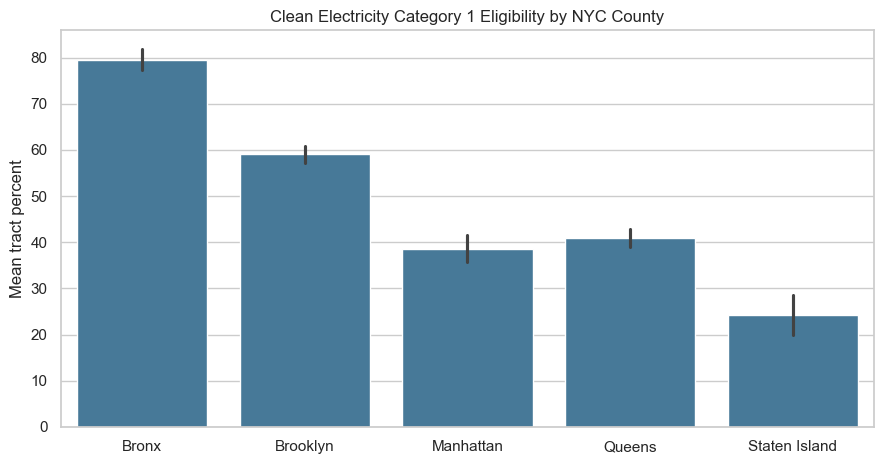

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(
    data=tract_features,
    x="county_name",
    y="clean_category1_pct",
    estimator=np.mean,
    errorbar="se",  # show within-county tract SE
    order=["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"],
    ax=ax,
    color="#3A7CA5",
)
ax.set_xlabel("")
ax.set_ylabel("Mean tract percent")
ax.set_title("Clean Electricity Category 1 Eligibility by NYC County")
fig.tight_layout()
fig.savefig(OUT_DIR / "clean_category1_by_county.png", dpi=160)
plt.show()

## Build 2014-2023 Panels

The tract-year panel is balanced across all tracts and years, with zero-outage cells filled where no event appears. Because the outage event data largely repeats outage conditions across tracts within county-years, tract-level occurrence models are diagnostic/descriptive rather than the main inferential result.

In [8]:
annual_counts = outage.groupby(["tract_fips", "county_fips", "year"], as_index=False).agg(
    outage_occurrence=("outage_event_uid", "nunique"),
    outage_duration_mean=("duration_hours", "mean"),
    outage_duration_median=("duration_hours", "median"),
    severe_weather_count=("severe_weather_flag", "sum"),
    outage_mean_customers_mean=("outage_mean_customers", "mean"),
)
tract_year_grid = (
    tract_features[["tract_fips", "county_fips"]]
    .assign(key=1)
    .merge(pd.DataFrame({"year": range(2014, 2024), "key": 1}), on="key")
    .drop(columns="key")
)
annual = tract_year_grid.merge(annual_counts, on=["tract_fips", "county_fips", "year"], how="left")
annual[["outage_occurrence", "severe_weather_count"]] = annual[["outage_occurrence", "severe_weather_count"]].fillna(0)
annual = annual.merge(tract_features, on=["tract_fips", "county_fips"], how="left")
annual["county_name"] = annual["county_fips"].map(NYC_COUNTIES)
annual["year_centered"] = annual["year"] - annual["year"].mean()
annual["log_outage_occurrence"] = np.log1p(annual["outage_occurrence"])
annual["log_outage_duration_mean"] = np.log1p(annual["outage_duration_mean"])
annual["log_outage_mean_customers"] = np.log1p(annual["outage_mean_customers_mean"])
annual_matched = annual[annual["clean_direct_match"]].copy()
annual_matched = zscore(annual_matched, [
    "severe_weather_count", "outage_mean_customers_mean",
    "clean_category1_pct", "clean_asc_ppc_pct", "clean_asc_cejst_e_pct", "clean_any_eligible_pct",
    *CVI_COLS,
])

print("Balanced tract-year rows:", len(annual))
print("Matched tract-year rows:", len(annual_matched))
print("Zero-outage tract-year cells:", int((annual["outage_occurrence"] == 0).sum()))
annual_matched.to_csv(OUT_DIR / "clean_electricity_annual_tract_panel.csv", index=False)

Balanced tract-year rows: 21680
Matched tract-year rows: 20330
Zero-outage tract-year cells: 687


## Policy Alignment: Historical Outage Burden vs Current Eligibility

Because the Clean Electricity workbook is a 2025/current eligibility layer, it should not be interpreted as a year-by-year exposure for 2014-2023. The more defensible question is policy alignment: do today's Clean Electricity low-income eligibility areas overlap with communities that carried heavier historical outage burden during 2014-2023?

This section summarizes 2014-2023 outage burden for each tract and compares it with the current Category 1 eligibility percentage.

In [9]:
tract_burden = (
    outage.dropna(subset=["tract_fips", "county_fips"])
    .groupby(["tract_fips", "county_fips"], as_index=False)
    .agg(
        historical_outage_events=("outage_event_uid", "nunique"),
        active_outage_years=("year", "nunique"),
        mean_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        p90_duration_hours=("duration_hours", lambda s: s.quantile(0.90)),
        long_outage_8h_share=("duration_hours", lambda s: (s >= 8).mean()),
        long_outage_24h_share=("duration_hours", lambda s: (s >= 24).mean()),
        severe_weather_events=("severe_weather_flag", "sum"),
        mean_customers=("outage_mean_customers", "mean"),
    )
)
tract_burden = tract_features.merge(tract_burden, on=["tract_fips", "county_fips"], how="left")
for col in ["historical_outage_events", "active_outage_years", "severe_weather_events", "long_outage_8h_share", "long_outage_24h_share"]:
    tract_burden[col] = tract_burden[col].fillna(0)
tract_burden["events_per_active_year"] = tract_burden["historical_outage_events"] / tract_burden["active_outage_years"].replace(0, np.nan)
tract_burden["category1_bucket"] = pd.cut(
    tract_burden["clean_category1_pct"],
    bins=[-0.01, 0, 99.999, 100],
    labels=["0%", "Partial", "100%"],
)

policy_alignment_by_category1 = (
    tract_burden[tract_burden["clean_direct_match"]]
    .groupby("category1_bucket", observed=False)
    .agg(
        tracts=("tract_fips", "nunique"),
        mean_category1_pct=("clean_category1_pct", "mean"),
        mean_historical_events=("historical_outage_events", "mean"),
        median_historical_events=("historical_outage_events", "median"),
        mean_active_years=("active_outage_years", "mean"),
        mean_duration_hours=("mean_duration_hours", "mean"),
        mean_long_8h_share=("long_outage_8h_share", "mean"),
        mean_severe_weather_events=("severe_weather_events", "mean"),
        mean_cvi_social_econ=("cvi_baseline_social_econ", "mean"),
    )
    .reset_index()
)

policy_alignment_by_county = (
    tract_burden[tract_burden["clean_direct_match"]]
    .groupby("county_name", as_index=False)
    .agg(
        tracts=("tract_fips", "nunique"),
        mean_category1_pct=("clean_category1_pct", "mean"),
        mean_any_eligible_pct=("clean_any_eligible_pct", "mean"),
        mean_historical_events=("historical_outage_events", "mean"),
        median_historical_events=("historical_outage_events", "median"),
        mean_duration_hours=("mean_duration_hours", "mean"),
        mean_long_8h_share=("long_outage_8h_share", "mean"),
        mean_cvi_social_econ=("cvi_baseline_social_econ", "mean"),
    )
)

display(policy_alignment_by_category1.round(3))
display(policy_alignment_by_county.round(3))

tract_burden.to_csv(OUT_DIR / "policy_alignment_tract_burden.csv", index=False)
policy_alignment_by_category1.to_csv(OUT_DIR / "policy_alignment_by_category1.csv", index=False)
policy_alignment_by_county.to_csv(OUT_DIR / "policy_alignment_by_county.csv", index=False)

,category1_bucket,tracts,mean_category1_pct,mean_historical_events,median_historical_events,mean_active_years,mean_duration_hours,mean_long_8h_share,mean_severe_weather_events,mean_cvi_social_econ
0,0%,965,0.00,1142.027,1040.0,9.579,3.662,0.089,187.029,0.500
1,Partial,3,33.53,865.000,865.0,10.000,3.535,0.053,250.000,0.711
2,100%,1065,100.00,1089.592,1040.0,9.781,3.876,0.088,201.372,0.669


,county_name,tracts,mean_category1_pct,mean_any_eligible_pct,mean_historical_events,median_historical_events,mean_duration_hours,mean_long_8h_share,mean_cvi_social_econ
0,Bronx,323,79.568,100.000,865.0,865.0,3.535,0.053,0.760
1,Brooklyn,721,59.085,59.085,1040.0,1040.0,4.761,0.113,0.586
2,Manhattan,272,38.603,38.603,262.0,262.0,3.473,0.129,0.465
3,Queens,622,40.997,41.147,1786.0,1786.0,2.957,0.071,0.573
4,Staten Island,95,24.211,24.211,565.0,565.0,3.307,0.021,0.490


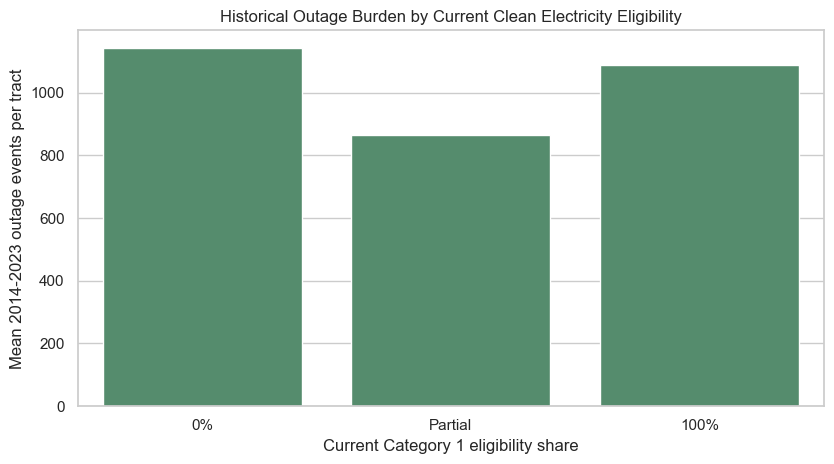

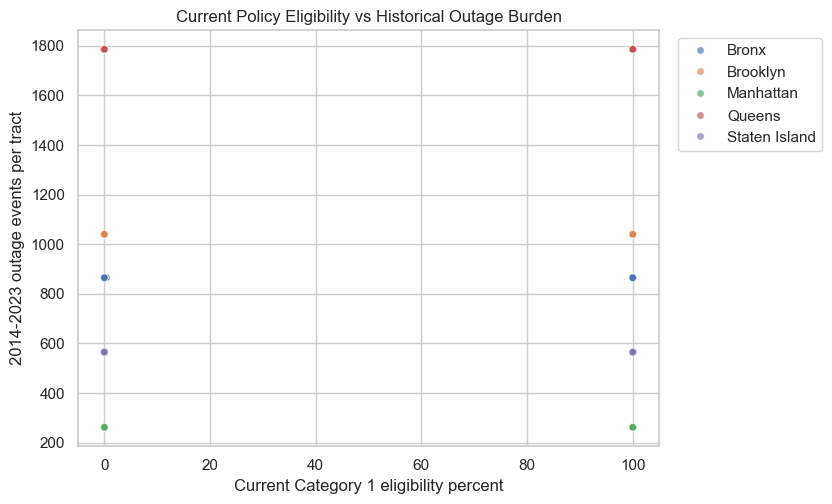

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(
    data=policy_alignment_by_category1,
    x="category1_bucket",
    y="mean_historical_events",
    color="#4C956C",
    ax=ax,
)
ax.set_xlabel("Current Category 1 eligibility share")
ax.set_ylabel("Mean 2014-2023 outage events per tract")
ax.set_title("Historical Outage Burden by Current Clean Electricity Eligibility")
fig.tight_layout()
fig.savefig(OUT_DIR / "policy_alignment_category1_burden.png", dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.scatterplot(
    data=tract_burden[tract_burden["clean_direct_match"]],
    x="clean_category1_pct",
    y="historical_outage_events",
    hue="county_name",
    alpha=0.65,
    s=28,
    ax=ax,
)
ax.set_xlabel("Current Category 1 eligibility percent")
ax.set_ylabel("2014-2023 outage events per tract")
ax.set_title("Current Policy Eligibility vs Historical Outage Burden")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(OUT_DIR / "policy_alignment_scatter.png", dpi=160)
plt.show()

In [11]:
county_year = outage.groupby(["county_fips", "year"], as_index=False).agg(
    outage_occurrence=("outage_event_uid", "nunique"),
    outage_duration_mean=("duration_hours", "mean"),
    outage_duration_median=("duration_hours", "median"),
    severe_weather_count=("severe_weather_flag", "sum"),
    severe_weather_share=("severe_weather_flag", "mean"),
    outage_mean_customers_mean=("outage_mean_customers", "mean"),
)
county_grid = pd.MultiIndex.from_product(
    [sorted(NYC_COUNTIES), range(2014, 2024)], names=["county_fips", "year"]
).to_frame(index=False)
county_panel = county_grid.merge(county_year, on=["county_fips", "year"], how="left")
county_panel[["outage_occurrence", "severe_weather_count", "severe_weather_share"]] = county_panel[[
    "outage_occurrence", "severe_weather_count", "severe_weather_share"
]].fillna(0)
county_panel = county_panel.merge(county_features.drop(columns="county_name"), on="county_fips", how="left")
county_panel["county_name"] = county_panel["county_fips"].map(NYC_COUNTIES)
county_panel["year_centered"] = county_panel["year"] - county_panel["year"].mean()
county_panel["log_outage_occurrence"] = np.log1p(county_panel["outage_occurrence"])
county_panel["log_outage_duration_mean"] = np.log1p(county_panel["outage_duration_mean"])
county_panel["log_outage_mean_customers"] = np.log1p(county_panel["outage_mean_customers_mean"])
county_panel = zscore(county_panel, [
    "severe_weather_count", "severe_weather_share", "log_outage_mean_customers",
    "cvi_overall_mean", "cvi_baseline_social_econ_mean", "cvi_baseline_infra_mean", "cvi_climate_extreme_events_mean",
    "clean_category1_mean", "clean_asc_ppc_mean", "clean_asc_cejst_e_mean", "clean_any_eligible_mean",
])

display(county_panel.head())
county_panel.to_csv(OUT_DIR / "clean_electricity_county_panel.csv", index=False)

,county_fips,year,outage_occurrence,outage_duration_mean,outage_duration_median,severe_weather_count,severe_weather_share,outage_mean_customers_mean,matched_tracts,total_tracts,cvi_overall_mean,cvi_baseline_social_econ_mean,cvi_baseline_infra_mean,cvi_climate_extreme_events_mean,clean_category1_mean,clean_asc_ppc_mean,clean_asc_cejst_e_mean,clean_any_eligible_mean,match_rate,county_name,year_centered,log_outage_occurrence,log_outage_duration_mean,log_outage_mean_customers,z_severe_weather_count,z_severe_weather_share,z_log_outage_mean_customers,z_cvi_overall_mean,z_cvi_baseline_social_econ_mean,z_cvi_baseline_infra_mean,z_cvi_climate_extreme_events_mean,z_clean_category1_mean,z_clean_asc_ppc_mean,z_clean_asc_cejst_e_mean,z_clean_any_eligible_mean
0,36005,2014,6.0,1.125000,1.25,0.0,0.000000,410.769841,323,339,0.551359,0.760706,0.536977,0.370434,79.56839,99.996563,7.438978,100.0,0.952802,Bronx,-4.5,1.945910,0.753772,6.020465,-0.426415,-0.531489,-0.717637,1.603989,1.775972,1.453448,-0.713148,1.628137,2.0,1.528128,1.811541
1,36005,2015,69.0,1.659722,1.00,0.0,0.000000,625.108870,323,339,0.551359,0.760706,0.536977,0.370434,79.56839,99.996563,7.438978,100.0,0.952802,Bronx,-3.5,4.248495,0.978222,6.439524,-0.426415,-0.531489,-0.004062,1.603989,1.775972,1.453448,-0.713148,1.628137,2.0,1.528128,1.811541
2,36005,2016,76.0,2.067073,1.50,0.0,0.000000,585.660247,323,339,0.551359,0.760706,0.536977,0.370434,79.56839,99.996563,7.438978,100.0,0.952802,Bronx,-2.5,4.343805,1.120724,6.374446,-0.426415,-0.531489,-0.114878,1.603989,1.775972,1.453448,-0.713148,1.628137,2.0,1.528128,1.811541
3,36005,2017,64.0,2.242188,1.75,0.0,0.000000,578.829097,323,339,0.551359,0.760706,0.536977,0.370434,79.56839,99.996563,7.438978,100.0,0.952802,Bronx,-1.5,4.174387,1.176248,6.362733,-0.426415,-0.531489,-0.134822,1.603989,1.775972,1.453448,-0.713148,1.628137,2.0,1.528128,1.811541
4,36005,2018,105.0,4.246711,2.75,46443.0,0.450658,2189.097198,323,339,0.551359,0.760706,0.536977,0.370434,79.56839,99.996563,7.438978,100.0,0.952802,Bronx,-0.5,4.663439,1.657601,7.691701,1.926206,2.471482,2.128143,1.603989,1.775972,1.453448,-0.713148,1.628137,2.0,1.528128,1.811541


In [12]:
event_level = (
    outage.dropna(subset=["outage_event_uid", "duration_hours"])
    .sort_values(["county_fips", "year", "outage_event_uid"])
    .drop_duplicates(["county_fips", "year", "outage_event_uid"])
    [["county_fips", "year", "month", "outage_event_uid", "duration_hours", "severe_weather_flag", "outage_mean_customers"]]
    .merge(county_features.drop(columns="county_name"), on="county_fips", how="left")
)
event_level["county_name"] = event_level["county_fips"].map(NYC_COUNTIES)
event_level["year_centered"] = event_level["year"] - event_level["year"].mean()
event_level["log_duration"] = np.log1p(event_level["duration_hours"])
event_level["log_outage_mean_customers"] = np.log1p(event_level["outage_mean_customers"])
event_level = zscore(event_level, [
    "log_outage_mean_customers", "cvi_baseline_social_econ_mean", "cvi_baseline_infra_mean",
    "clean_category1_mean", "clean_any_eligible_mean",
])
print("Unique event-duration rows:", len(event_level))
event_level.to_csv(OUT_DIR / "clean_electricity_event_duration_panel.csv", index=False)

Unique event-duration rows: 4518


## Models

The models below are intentionally compact. **Tract-year models** include `C(county_fips)` which absorbs all cross-county variation; because outage occurrence is county-uniform, within-county variance in the outcome is near-zero — these specs are **diagnostic only**. **County-year and event-level models** are the interpretable evidence for whether the Clean Electricity layer adds signal beyond severe weather and CVI.

> Forest plot color guide: 🔴 red = tract-year (diagnostic, do not cite); 🔵 blue = county-year or event-level (interpretable).


In [13]:
specs = [
    (
        "tract_year_category1",
        "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_baseline_social_econ + z_clean_category1_pct + C(county_fips)",
        annual_matched,
    ),
    (
        "tract_year_any_eligible",
        "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_baseline_social_econ + z_clean_any_eligible_pct + C(county_fips)",
        annual_matched,
    ),
    (
        "county_year_category1",
        "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_baseline_social_econ_mean + z_clean_category1_mean",
        county_panel,
    ),
    (
        "county_year_any_eligible",
        "log_outage_occurrence ~ year_centered + z_severe_weather_count + z_cvi_baseline_social_econ_mean + z_clean_any_eligible_mean",
        county_panel,
    ),
    (
        "event_duration_category1",
        "log_duration ~ year_centered + severe_weather_flag + z_log_outage_mean_customers + z_cvi_baseline_social_econ_mean + z_clean_category1_mean",
        event_level.dropna(subset=["log_duration", "z_log_outage_mean_customers"]),
    ),
    (
        "event_duration_any_eligible",
        "log_duration ~ year_centered + severe_weather_flag + z_log_outage_mean_customers + z_cvi_baseline_social_econ_mean + z_clean_any_eligible_mean",
        event_level.dropna(subset=["log_duration", "z_log_outage_mean_customers"]),
    ),
]

model_rows = []
coef_frames = []
print("Model sample sizes:")
for label, formula, data in specs:
    print(f"  {label}: N={len(data)}")
    model_row, coef_df = fit_ols(formula, data, label)
    model_rows.append(model_row)
    coef_frames.append(coef_df)

model_summary = pd.DataFrame(model_rows)
coef_summary = pd.concat(coef_frames, ignore_index=True)
key_terms = coef_summary[coef_summary["term"].str.contains("clean_|cvi_baseline_social_econ", regex=True)].copy()

display(model_summary.round(3))
display(key_terms[["model", "term", "coef", "std_error", "p_value", "ci_lower", "ci_upper"]].round(4))

model_summary.to_csv(OUT_DIR / "clean_electricity_model_summary.csv", index=False)
coef_summary.to_csv(OUT_DIR / "clean_electricity_coef_summary.csv", index=False)
key_terms.to_csv(OUT_DIR / "clean_electricity_key_terms.csv", index=False)

Model sample sizes:
  tract_year_category1: N=20330
  tract_year_any_eligible: N=20330
  county_year_category1: N=50
  county_year_any_eligible: N=50
  event_duration_category1: N=4518
  event_duration_any_eligible: N=4518


,model,formula,nobs,r2,adj_r2,aic,bic
0,tract_year_category1,log_outage_occurrence ~ year_centered + z_seve...,20330,0.532,0.532,50748.612,50819.891
1,tract_year_any_eligible,log_outage_occurrence ~ year_centered + z_seve...,20330,0.532,0.532,50748.612,50819.891
2,county_year_category1,log_outage_occurrence ~ year_centered + z_seve...,50,0.332,0.272,165.799,175.359
3,county_year_any_eligible,log_outage_occurrence ~ year_centered + z_seve...,50,0.408,0.355,159.778,169.338
4,event_duration_category1,log_duration ~ year_centered + severe_weather_...,4518,0.062,0.061,10118.543,10157.038
5,event_duration_any_eligible,log_duration ~ year_centered + severe_weather_...,4518,0.051,0.050,10168.512,10207.007


,model,term,coef,std_error,p_value,ci_lower,ci_upper
7,tract_year_category1,z_cvi_baseline_social_econ,-0.0000,0.0100,1.0000,-0.0197,0.0197
8,tract_year_category1,z_clean_category1_pct,-0.0000,0.0072,1.0000,-0.0140,0.0140
16,tract_year_any_eligible,z_cvi_baseline_social_econ,-0.0000,0.0095,1.0000,-0.0186,0.0186
17,tract_year_any_eligible,z_clean_any_eligible_pct,0.0000,0.0074,1.0000,-0.0145,0.0145
21,county_year_category1,z_cvi_baseline_social_econ_mean,1.0528,0.4762,0.0271,0.1194,1.9862
22,county_year_category1,z_clean_category1_mean,-0.6647,0.4756,0.1623,-1.5969,0.2676
26,county_year_any_eligible,z_cvi_baseline_social_econ_mean,1.8219,0.5863,0.0019,0.6728,2.9710
27,county_year_any_eligible,z_clean_any_eligible_mean,-1.4482,0.5607,0.0098,-2.5472,-0.3493
32,event_duration_category1,z_cvi_baseline_social_econ_mean,-0.2571,0.0308,0.0000,-0.3175,-0.1967
33,event_duration_category1,z_clean_category1_mean,0.3224,0.0305,0.0000,0.2626,0.3822


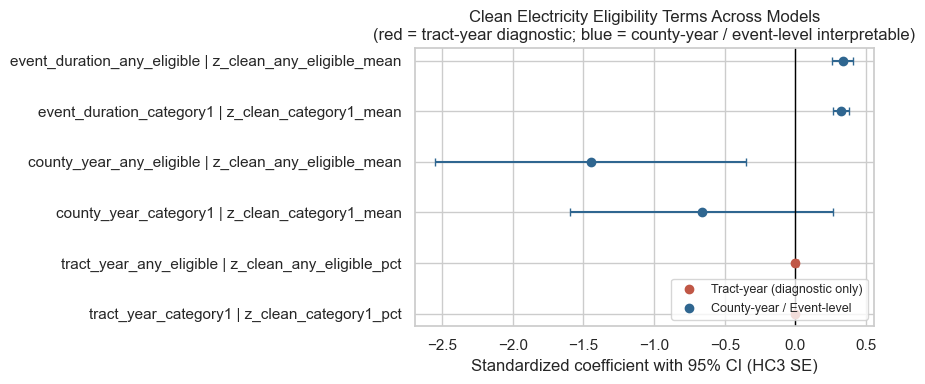

In [14]:
plot_terms = [
    "z_clean_category1_pct",
    "z_clean_any_eligible_pct",
    "z_clean_category1_mean",
    "z_clean_any_eligible_mean",
]
forest = key_terms[key_terms["term"].isin(plot_terms)].copy()
forest["label"] = forest["model"] + " | " + forest["term"]
# Color by model level: tract-year = red (diagnostic); county/event = blue (interpretable)
forest["color"] = forest["model"].apply(
    lambda m: "#C05746" if m.startswith("tract_year") else "#2F6690"
)

fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(forest))))
y = np.arange(len(forest))
for idx, (_, row) in enumerate(forest.iterrows()):
    ax.errorbar(
        row["coef"], idx,
        xerr=[[row["coef"] - row["ci_lower"]], [row["ci_upper"] - row["coef"]]],
        fmt="o", color=row["color"], ecolor=row["color"], capsize=3,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(forest["label"])
ax.set_xlabel("Standardized coefficient with 95% CI (HC3 SE)")
ax.set_title(
    "Clean Electricity Eligibility Terms Across Models\n"
    "(red = tract-year diagnostic; blue = county-year / event-level interpretable)"
)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="#C05746", label="Tract-year (diagnostic only)", lw=0),
    Line2D([0], [0], marker="o", color="#2F6690", label="County-year / Event-level", lw=0),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "clean_electricity_model_forest.png", dpi=160)
plt.show()


## Interpretation

### Q1: How much of the NYC outage/CVI tract universe matches the 2025 Clean Electricity layer?
The workbook directly matches **2,033 of 2,168 NYC outage/CVI tracts (93.8%)**. The 6.2% gap is consistent with tract boundary changes between the outage/CVI geography and the 2025 tract layer. A Census tract crosswalk would improve exact tract-level coverage.

### Q2: How do Clean Electricity eligibility measures compare with CVI?
Category 1 eligibility is strongly correlated with social-economic CVI. This means the Clean Electricity layer is useful as a policy eligibility lens, but it is not a completely independent vulnerability measure. It helps answer whether communities currently recognized by clean-energy low-income policy overlap with communities that appear vulnerable in the CVI framework.

### Q3: Do current Clean Electricity eligible communities show higher historical outage burden?
The answer is mixed. Tracts with **100% Category 1 eligibility** have higher average social-economic CVI than **0% Category 1** tracts, but their historical outage event counts are similar rather than sharply higher. In the direct-match tract set, 100% Category 1 tracts average about **1,090 outage events** over 2014-2023, compared with about **1,142 events** for 0% Category 1 tracts. This means the policy layer captures social vulnerability clearly, but it does not perfectly identify the highest historical outage-count burden.

### Q4: Does the eligibility layer add signal to compact outage models beyond weather and CVI?
Only cautiously. The county-year and event-duration models are useful sensitivity checks, but county-level variation is small and eligibility is cross-sectional. The strongest claim should remain descriptive and policy-facing: current Clean Electricity eligibility partly overlaps with historical outage vulnerability and social vulnerability, but it should not be treated as a causal, time-varying outage predictor.

### Recommended use in the main project
Use this notebook as a policy-alignment extension to the main outage/CVI analysis. The cleanest framing is: **historical outage burden versus current clean-energy low-income eligibility**. For stronger tract-level inference, add a Census tract crosswalk and, ideally, a more granular utility outage dataset where outage outcomes vary independently by tract.
